# Churn Classification Model
**Objective:** Predict customer churn using classical ML models.

**Metric:** ROC-AUC (robust to class imbalance, standard for churn tasks)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier

from assets.encode_features import encode_features

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 1. Load & Clean Data

In [2]:
df = pd.read_csv("assets/data.csv")
df.columns = df.columns.str.lower().str.strip()

In [3]:
# total_charges is read as string due to whitespace entries on tenure=0 rows
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce").fillna(0)

In [4]:
# Normalize all string columns: lowercase, replace spaces/dashes with underscore
str_cols = df.select_dtypes("str").columns
df[str_cols] = df[str_cols].apply(
    lambda c: c.str.lower().str.strip()
               .str.replace(r"[ \-]", "_", regex=True)
               .str.replace(r"[()]", "", regex=True)
)

In [5]:
# Drop identifier — carries no predictive signal
df.drop(columns=["customerid"], inplace=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 20)


,gender,senior_citizen,is_married,dependents,tenure,phone_service,dual,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,female,0,yes,no,1,no,no_phone_service,dsl,no,yes,no,no,no,no,month_to_month,yes,electronic_check,29.85,29.85,no
1,male,0,no,no,34,yes,no,dsl,yes,no,yes,no,no,no,one_year,no,mailed_check,56.95,1889.50,no
2,male,0,no,no,2,yes,no,dsl,yes,yes,no,no,no,no,month_to_month,yes,mailed_check,53.85,108.15,yes
3,male,0,no,no,45,no,no_phone_service,dsl,yes,no,yes,yes,no,no,one_year,no,bank_transfer_automatic,42.30,1840.75,no
4,female,0,no,no,2,yes,no,fiber_optic,no,no,no,no,no,no,month_to_month,yes,electronic_check,70.70,151.65,yes


### Quick Data Summary

In [6]:
def summary(df):
    s = pd.DataFrame(df.dtypes, columns=["dtype"])
    s["missing #"] = df.isna().sum()
    s["missing %"] = (df.isna().sum() / len(df) * 100).round(2)
    s["unique"]    = df.nunique()
    s["count"]     = df.count()
    return s

summary(df)

,dtype,missing #,missing %,unique,count
gender,str,0,0.0,2,7043
senior_citizen,int64,0,0.0,2,7043
is_married,str,0,0.0,2,7043
dependents,str,0,0.0,2,7043
tenure,int64,0,0.0,73,7043
phone_service,str,0,0.0,2,7043
dual,str,0,0.0,3,7043
internet_service,str,0,0.0,3,7043
online_security,str,0,0.0,3,7043
online_backup,str,0,0.0,3,7043


### Target Distribution

Class imbalance ratio ~2.77:1 — we will use **`class_weight='balanced'`** for

sklearn models and **`scale_pos_weight`** for XGBoost instead of resampling,

which keeps the validation distribution honest.

No: 5,174 (73.5%)  |  Yes: 1,869 (26.5%)
Imbalance ratio: 2.77:1


C:\Users\ahmed\AppData\Local\Temp\ipykernel_26292\1460109879.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="churn", palette="Set2", ax=axes[0])


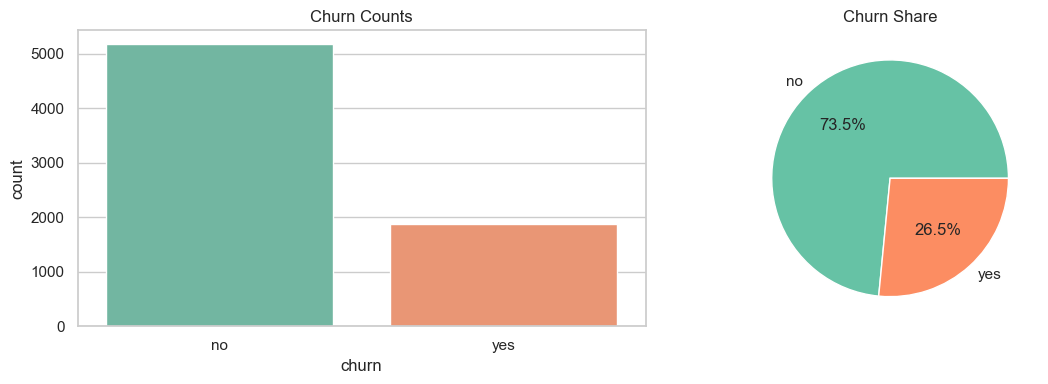

In [7]:
churn_counts = df["churn"].value_counts()
neg, pos     = churn_counts["no"], churn_counts["yes"]
imbalance_ratio = neg / pos
print(f"No: {neg:,} ({neg/len(df)*100:.1f}%)  |  Yes: {pos:,} ({pos/len(df)*100:.1f}%)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="churn", palette="Set2", ax=axes[0])
axes[0].set_title("Churn Counts")
axes[1].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"))
axes[1].set_title("Churn Share")
plt.tight_layout()
plt.show()

## 2. Encoding


In [8]:
df_encoded = encode_features(df)
print(f"Encoded shape: {df_encoded.shape}")
df_encoded.head()

Encoded shape: (7043, 25)


,gender,senior_citizen,is_married,dependents,tenure,phone_service,dual,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,monthly_charges,total_charges,churn,internet_service_dsl,internet_service_fiber_optic,internet_service_no,payment_method_bank_transfer_automatic,payment_method_credit_card_automatic,payment_method_electronic_check,payment_method_mailed_check
0,0,0,1,0,1,0,0,1,2,1,1,1,1,0,1,29.85,29.85,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,1,2,1,2,1,1,1,1,0,56.95,1889.50,0,1,0,0,0,0,0,1
2,1,0,0,0,2,1,1,2,2,1,1,1,1,0,1,53.85,108.15,1,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,2,1,2,2,1,1,1,0,42.30,1840.75,0,1,0,0,1,0,0,0
4,0,0,0,0,2,1,1,1,1,1,1,1,1,0,1,70.70,151.65,1,0,1,0,0,0,1,0


## 3. Train / Validation / Test Split

Strategy: **60 / 20 / 20** with stratification to preserve class ratio in all splits.
- `df_train`     → fit models
- `df_val`       → compare & select models
- `df_test`      → final unbiased evaluation of the winner

In [9]:
df_train_full, df_test = train_test_split(df_encoded, test_size=0.2,
                                          random_state=1, stratify=df_encoded["churn"])
df_train, df_val       = train_test_split(df_train_full, test_size=0.25,
                                          random_state=1, stratify=df_train_full["churn"])

for name, split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    n_pos = split["churn"].sum()
    print(f"{name:5s}: {len(split):,} rows | churn rate: {n_pos/len(split)*100:.1f}%")

def Xy(df):
    return df.drop(columns=["churn"]), df["churn"].values

X_train, y_train = Xy(df_train)
X_val,   y_val   = Xy(df_val)
X_test,  y_test  = Xy(df_test)
X_full,  y_full  = Xy(df_train_full)

Train: 4,225 rows | churn rate: 26.5%
Val  : 1,409 rows | churn rate: 26.5%
Test : 1,409 rows | churn rate: 26.5%


## 4. Baseline Models

We evaluate 4 models on the validation set first.

All are configured to handle class imbalance natively.


In [10]:
SEED = 1

baselines = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=SEED
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, class_weight="balanced", random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, scale_pos_weight=imbalance_ratio,
        eval_metric="auc", random_state=SEED,
        verbosity=0, use_label_encoder=False
    ),
}

baseline_results = {}
for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    baseline_results[name] = auc
    print(f"{name:<25} Val AUC: {auc:.4f}")

d:\Ahmed\GitHub projects\AI-Powered-Assistant-for-Churn-Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression       Val AUC: 0.8434
Decision Tree             Val AUC: 0.8118
Random Forest             Val AUC: 0.8340
XGBoost                   Val AUC: 0.8225


## 5. Hyperparameter Tuning

We tune the **top 2** performers (typically RF and XGBoost).

Using **StratifiedKFold CV on the full training set** to get stable estimates.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

── Random Forest ──────────────────────────────────────────────────────────────


In [12]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth":    [None, 10, 20],
    "min_samples_leaf": [1, 5, 10],
}

best_rf_auc, best_rf_params, best_rf_model = 0, None, None

total = (len(rf_param_grid["n_estimators"]) *
         len(rf_param_grid["max_depth"]) *
         len(rf_param_grid["min_samples_leaf"]))

print(f"Tuning Random Forest ({total} combinations × 5 folds)...")
for n_est in rf_param_grid["n_estimators"]:
    for depth in rf_param_grid["max_depth"]:
        for leaf in rf_param_grid["min_samples_leaf"]:
            rf = RandomForestClassifier(
                n_estimators=n_est, max_depth=depth,
                min_samples_leaf=leaf,
                class_weight="balanced", random_state=SEED, n_jobs=-1
            )
            scores = cross_val_score(rf, X_full, y_full, cv=cv,
                                     scoring="roc_auc", n_jobs=-1)
            auc = scores.mean()
            if auc > best_rf_auc:
                best_rf_auc    = auc
                best_rf_params = {"n_estimators": n_est, "max_depth": depth,
                                  "min_samples_leaf": leaf}
                best_rf_model  = rf

print(f"Best RF  → AUC: {best_rf_auc:.4f} | Params: {best_rf_params}")

Tuning Random Forest (27 combinations × 5 folds)...
Best RF  → AUC: 0.8512 | Params: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10}


── XGBoost ────────────────────────────────────────────────────────────────────

In [13]:
xgb_param_grid = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample":     [0.8, 1.0],
}

best_xgb_auc, best_xgb_params, best_xgb_model = 0, None, None

total_xgb = (len(xgb_param_grid["n_estimators"]) *
             len(xgb_param_grid["max_depth"]) *
             len(xgb_param_grid["learning_rate"]) *
             len(xgb_param_grid["subsample"]))

print(f"\nTuning XGBoost ({total_xgb} combinations × 5 folds)...")
for n_est in xgb_param_grid["n_estimators"]:
    for depth in xgb_param_grid["max_depth"]:
        for lr in xgb_param_grid["learning_rate"]:
            for sub in xgb_param_grid["subsample"]:
                xgb_model = XGBClassifier(
                    n_estimators=n_est, max_depth=depth,
                    learning_rate=lr, subsample=sub,
                    scale_pos_weight=imbalance_ratio,
                    eval_metric="auc", random_state=SEED,
                    verbosity=0, use_label_encoder=False
                )
                scores = cross_val_score(xgb_model, X_full, y_full, cv=cv,
                                         scoring="roc_auc", n_jobs=-1)
                auc = scores.mean()
                if auc > best_xgb_auc:
                    best_xgb_auc    = auc
                    best_xgb_params = {"n_estimators": n_est, "max_depth": depth,
                                       "learning_rate": lr, "subsample": sub}
                    best_xgb_model  = xgb_model

print(f"Best XGB → AUC: {best_xgb_auc:.4f} | Params: {best_xgb_params}")



Tuning XGBoost (54 combinations × 5 folds)...
Best XGB → AUC: 0.8503 | Params: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.8}


## 6. Model Comparison Summary

                                 ROC-AUC
Random Forest (tuned)           0.851199
XGBoost (tuned)                 0.850269
Logistic Regression (baseline)  0.843367
Random Forest (baseline)        0.834000
XGBoost (baseline)              0.822499
Decision Tree (baseline)        0.811787


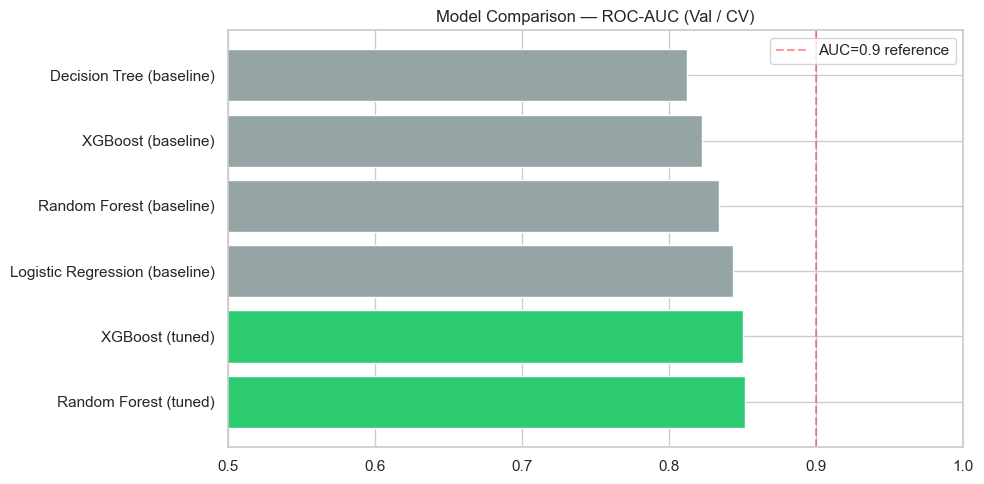

In [14]:
results = {
    **{f"{k} (baseline)": v for k, v in baseline_results.items()},
    f"Random Forest (tuned)": best_rf_auc,
    f"XGBoost (tuned)":       best_xgb_auc,
}

results_df = (pd.DataFrame.from_dict(results, orient="index", columns=["ROC-AUC"])
              .sort_values("ROC-AUC", ascending=False))

print(results_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if "tuned" in k else "#95a5a6" for k in results_df.index]
ax.barh(results_df.index, results_df["ROC-AUC"], color=colors)
ax.set_xlim(0.5, 1.0)
ax.axvline(0.9, linestyle="--", color="red", alpha=0.4, label="AUC=0.9 reference")
ax.set_title("Model Comparison — ROC-AUC (Val / CV)")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Final Evaluation on Hold-Out Test Set
Re-train the winning model on the **full training data** (train + val),

then evaluate once on the untouched test set.

In [15]:
# Determine winner
winner_name = "XGBoost" if best_xgb_auc >= best_rf_auc else "Random Forest"
winner_params = best_xgb_params if winner_name == "XGBoost" else best_rf_params
print(f"Winner: {winner_name}")
print(f"Params: {winner_params}")

if winner_name == "XGBoost":
    final_model = XGBClassifier(
        **winner_params,
        scale_pos_weight=imbalance_ratio,
        eval_metric="auc", random_state=SEED,
        verbosity=0, use_label_encoder=False
    )
else:
    final_model = RandomForestClassifier(
        **winner_params,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    )

# Fit on full training data (train + val)
final_model.fit(X_full, y_full)

# Evaluate on test set
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_test_proba)
print(f"\nTest ROC-AUC: {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["No Churn", "Churn"]))


Winner: Random Forest
Params: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10}

Test ROC-AUC: 0.8356

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



### Confusion Matrix & Feature Importance


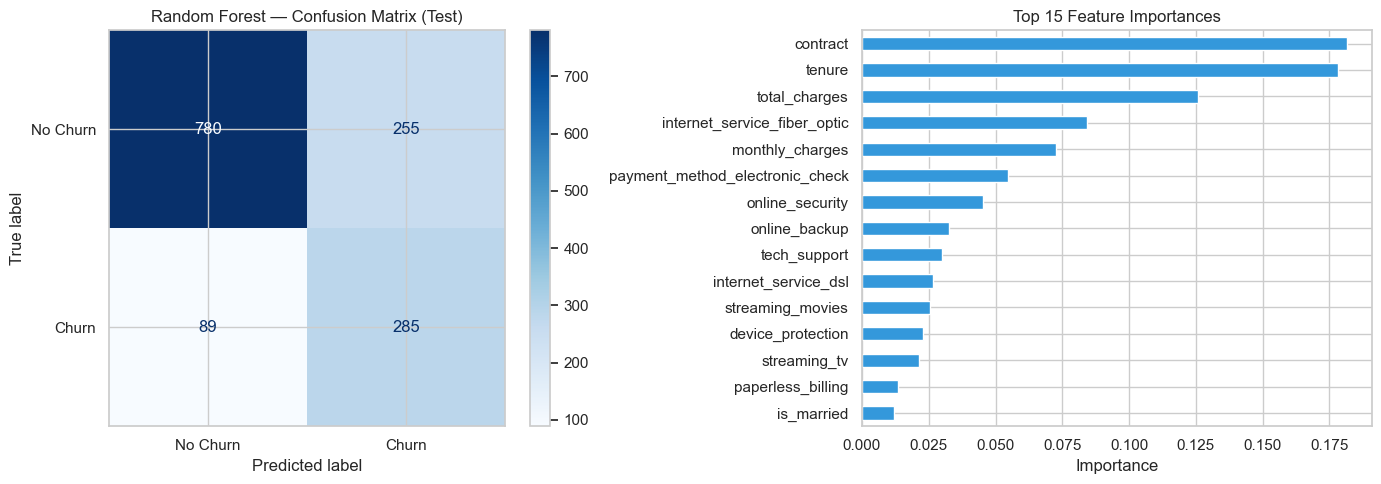

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"{winner_name} — Confusion Matrix (Test)")

# Feature importance
feat_imp = pd.Series(
    final_model.feature_importances_,
    index=X_full.columns
).sort_values(ascending=True).tail(15)

feat_imp.plot(kind="barh", ax=axes[1], color="#3498db")
axes[1].set_title("Top 15 Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


## 8. CatBoost Deep-Dive
CatBoost can consume raw categorical strings directly — no encoding needed.

We run 4 experiments to measure the encoding impact:

| # | Data          | Model              |
|---|---------------|--------------------|
| A | Raw (no enc)  | CatBoost baseline  |
| B | Raw (no enc)  | CatBoost tuned     |
| C | Encoded       | CatBoost baseline  |
| D | Encoded       | CatBoost tuned     |

**Why this matters:** CatBoost uses an internal ordered target-statistics
encoding that is leak-free by design. Manual encoding might add or remove
information depending on how it was done, so this comparison is meaningful.

In [17]:
from catboost import CatBoostClassifier, Pool
from assets.encode_features import TARGET_MAP   # reuse the yes/no → 1/0 map

── Prepare RAW splits (string categoricals intact, target mapped to 0/1) ─────

In [18]:
df_raw = df.copy()   # df is already lowercased/normalized from section 1
df_raw["churn"] = df_raw["churn"].map(TARGET_MAP)

df_raw_train_full, df_raw_test = train_test_split(df_raw, test_size=0.2,
                                                   random_state=1,
                                                   stratify=df_raw["churn"])
df_raw_train, df_raw_val       = train_test_split(df_raw_train_full, test_size=0.25,
                                                   random_state=1,
                                                   stratify=df_raw_train_full["churn"])


In [19]:
# All object columns except the target are categorical features for CatBoost
cat_features_raw = (df_raw.select_dtypes("str")
                          .columns.drop("churn", errors="ignore")
                          .tolist())
print(f"Raw cat features ({len(cat_features_raw)}): {cat_features_raw}")

def Xy_raw(split):
    return split.drop(columns=["churn"]), split["churn"].values

Xr_train, yr_train = Xy_raw(df_raw_train)
Xr_val,   yr_val   = Xy_raw(df_raw_val)
Xr_test,  yr_test  = Xy_raw(df_raw_test)
Xr_full,  yr_full  = Xy_raw(df_raw_train_full)

# CatBoost Pool objects carry cat_features metadata internally
pool_train_raw = Pool(Xr_train, yr_train, cat_features=cat_features_raw)
pool_val_raw   = Pool(Xr_val,   yr_val,   cat_features=cat_features_raw)
pool_full_raw  = Pool(Xr_full,  yr_full,  cat_features=cat_features_raw)
pool_test_raw  = Pool(Xr_test,  yr_test,  cat_features=cat_features_raw)

pool_train_enc = Pool(X_train, y_train)
pool_val_enc   = Pool(X_val,   y_val)
pool_full_enc  = Pool(X_full,  y_full)
pool_test_enc  = Pool(X_test,  y_test)

Raw cat features (15): ['gender', 'is_married', 'dependents', 'phone_service', 'dual', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']


### 8A & 8C — Baseline CatBoost (raw vs encoded)

In [20]:
CB_BASE_PARAMS = dict(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    auto_class_weights="Balanced",  # native imbalance handling
    eval_metric="AUC",
    random_seed=SEED,
    verbose=0,
)

cb_base_raw = CatBoostClassifier(**CB_BASE_PARAMS)
cb_base_raw.fit(pool_train_raw, eval_set=pool_val_raw)
auc_cb_base_raw = roc_auc_score(yr_val, cb_base_raw.predict_proba(pool_val_raw)[:, 1])
print(f"CatBoost baseline  (raw):     Val AUC = {auc_cb_base_raw:.4f}")

cb_base_enc = CatBoostClassifier(**CB_BASE_PARAMS)
cb_base_enc.fit(pool_train_enc, eval_set=pool_val_enc)
auc_cb_base_enc = roc_auc_score(y_val, cb_base_enc.predict_proba(pool_val_enc)[:, 1])
print(f"CatBoost baseline  (encoded): Val AUC = {auc_cb_base_enc:.4f}")

CatBoost baseline  (raw):     Val AUC = 0.8444
CatBoost baseline  (encoded): Val AUC = 0.8470


### 8B & 8D — Tuned CatBoost (raw vs encoded)

Grid search over the parameters that matter most for CatBoost.

In [21]:
cb_param_grid = {
    "iterations":    [300, 500, 800],
    "depth":         [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg":   [1, 3, 5],
}

total_cb = (len(cb_param_grid["iterations"]) *
            len(cb_param_grid["depth"]) *
            len(cb_param_grid["learning_rate"]) *
            len(cb_param_grid["l2_leaf_reg"]))

print(f"Tuning CatBoost ({total_cb} combinations × 5 folds × 2 datasets)...")

best_cb_raw = {"auc": 0, "params": None}
best_cb_enc = {"auc": 0, "params": None}

cv_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for iters in cb_param_grid["iterations"]:
    for depth in cb_param_grid["depth"]:
        for lr in cb_param_grid["learning_rate"]:
            for l2 in cb_param_grid["l2_leaf_reg"]:
                params = dict(
                    iterations=iters, depth=depth, learning_rate=lr,
                    l2_leaf_reg=l2, auto_class_weights="Balanced",
                    eval_metric="AUC", random_seed=SEED, verbose=0
                )

                # ── CV on RAW ────────────────────────────────────────────────
                fold_aucs = []
                for tr_idx, vl_idx in cv_skf.split(Xr_full, yr_full):
                    m = CatBoostClassifier(**params)
                    m.fit(
                        Pool(Xr_full.iloc[tr_idx], yr_full[tr_idx], cat_features=cat_features_raw),
                        eval_set=Pool(Xr_full.iloc[vl_idx], yr_full[vl_idx], cat_features=cat_features_raw),
                    )
                    fold_aucs.append(
                        roc_auc_score(yr_full[vl_idx], m.predict_proba(Xr_full.iloc[vl_idx])[:, 1])
                    )
                if (auc := np.mean(fold_aucs)) > best_cb_raw["auc"]:
                    best_cb_raw = {"auc": auc, "params": params}

                # ── CV on ENCODED ─────────────────────────────────────────────
                fold_aucs = []
                for tr_idx, vl_idx in cv_skf.split(X_full, y_full):
                    m = CatBoostClassifier(**params)
                    m.fit(
                        Pool(X_full.iloc[tr_idx], y_full[tr_idx]),
                        eval_set=Pool(X_full.iloc[vl_idx], y_full[vl_idx]),
                    )
                    fold_aucs.append(
                        roc_auc_score(y_full[vl_idx], m.predict_proba(X_full.iloc[vl_idx])[:, 1])
                    )
                if (auc := np.mean(fold_aucs)) > best_cb_enc["auc"]:
                    best_cb_enc = {"auc": auc, "params": params}

print(f"Best CatBoost tuned (raw):     CV AUC = {best_cb_raw['auc']:.4f} | {best_cb_raw['params']}")
print(f"Best CatBoost tuned (encoded): CV AUC = {best_cb_enc['auc']:.4f} | {best_cb_enc['params']}")


Tuning CatBoost (81 combinations × 5 folds × 2 datasets)...
Best CatBoost tuned (raw):     CV AUC = 0.8536 | {'iterations': 300, 'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'auto_class_weights': 'Balanced', 'eval_metric': 'AUC', 'random_seed': 1, 'verbose': 0}
Best CatBoost tuned (encoded): CV AUC = 0.8528 | {'iterations': 300, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'auto_class_weights': 'Balanced', 'eval_metric': 'AUC', 'random_seed': 1, 'verbose': 0}


### 8E — Final Test Evaluation for all 4 CatBoost variants
Re-fit each best config on the full training set, then evaluate once on test.


In [22]:
cb_tuned_raw = CatBoostClassifier(**best_cb_raw["params"])
cb_tuned_raw.fit(pool_full_raw)

cb_tuned_enc = CatBoostClassifier(**best_cb_enc["params"])
cb_tuned_enc.fit(pool_full_enc)

cb_experiments = {
    "CatBoost baseline (raw)":     (cb_base_raw,  pool_test_raw, yr_test),
    "CatBoost tuned   (raw)":      (cb_tuned_raw, pool_test_raw, yr_test),
    "CatBoost baseline (encoded)": (cb_base_enc,  pool_test_enc, y_test),
    "CatBoost tuned   (encoded)":  (cb_tuned_enc, pool_test_enc, y_test),
}

cb_results = {}
print(f"{'Experiment':<35} {'Test AUC':>10}")
print("─" * 47)
for label, (model, pool, y_true) in cb_experiments.items():
    auc = roc_auc_score(y_true, model.predict_proba(pool)[:, 1])
    cb_results[label] = auc
    print(f"{label:<35} {auc:>10.4f}")

Experiment                            Test AUC
───────────────────────────────────────────────
CatBoost baseline (raw)                 0.8359
CatBoost tuned   (raw)                  0.8357
CatBoost baseline (encoded)             0.8362
CatBoost tuned   (encoded)              0.8384


### CatBoost Visual Summary + Full Leaderboard

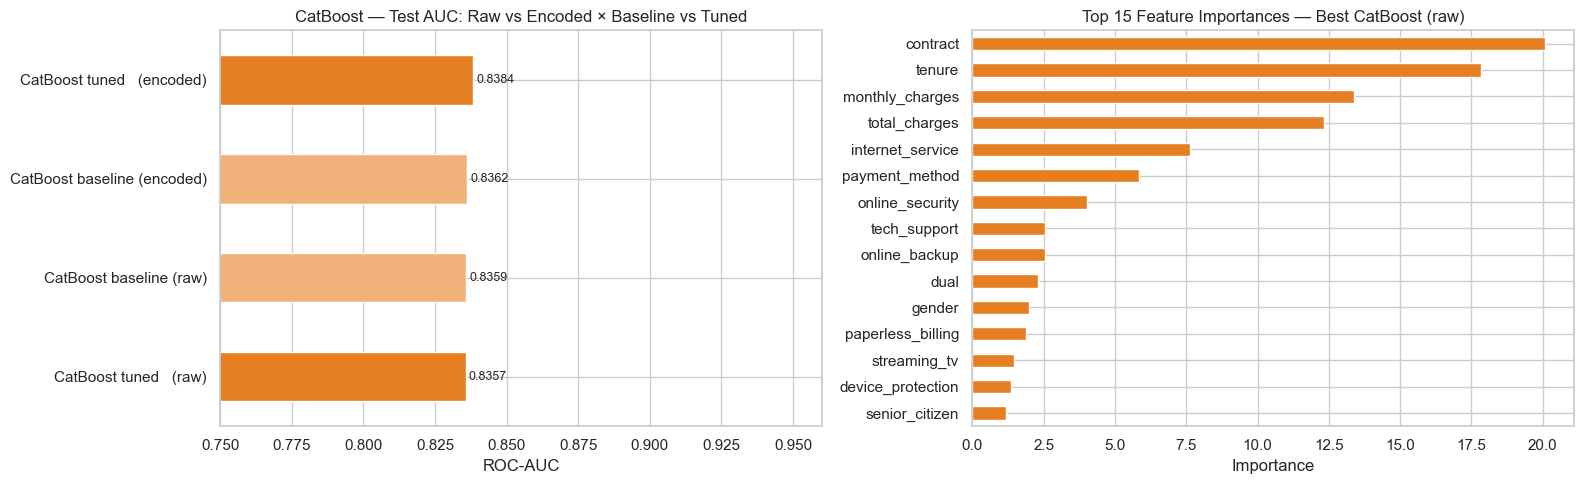

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── CatBoost bar chart ────────────────────────────────────────────────────────
cb_df = pd.Series(cb_results).sort_values()
bar_colors = ["#e67e22" if "tuned" in k else "#f0b27a" for k in cb_df.index]
cb_df.plot(kind="barh", ax=axes[0], color=bar_colors)
axes[0].set_xlim(0.75, 0.96)
axes[0].set_title("CatBoost — Test AUC: Raw vs Encoded × Baseline vs Tuned")
axes[0].set_xlabel("ROC-AUC")
for i, v in enumerate(cb_df):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

# ── Feature importance of best CatBoost overall ───────────────────────────────
best_cb_model = (cb_tuned_raw  if best_cb_raw["auc"] >= best_cb_enc["auc"]
                 else cb_tuned_enc)
best_label    = "raw" if best_cb_raw["auc"] >= best_cb_enc["auc"] else "encoded"

fi = pd.Series(
    best_cb_model.get_feature_importance(),
    index=best_cb_model.feature_names_
).sort_values(ascending=True).tail(15)

fi.plot(kind="barh", ax=axes[1], color="#e67e22")
axes[1].set_title(f"Top 15 Feature Importances — Best CatBoost ({best_label})")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

### Full Leaderboard — Every Model Side by Side

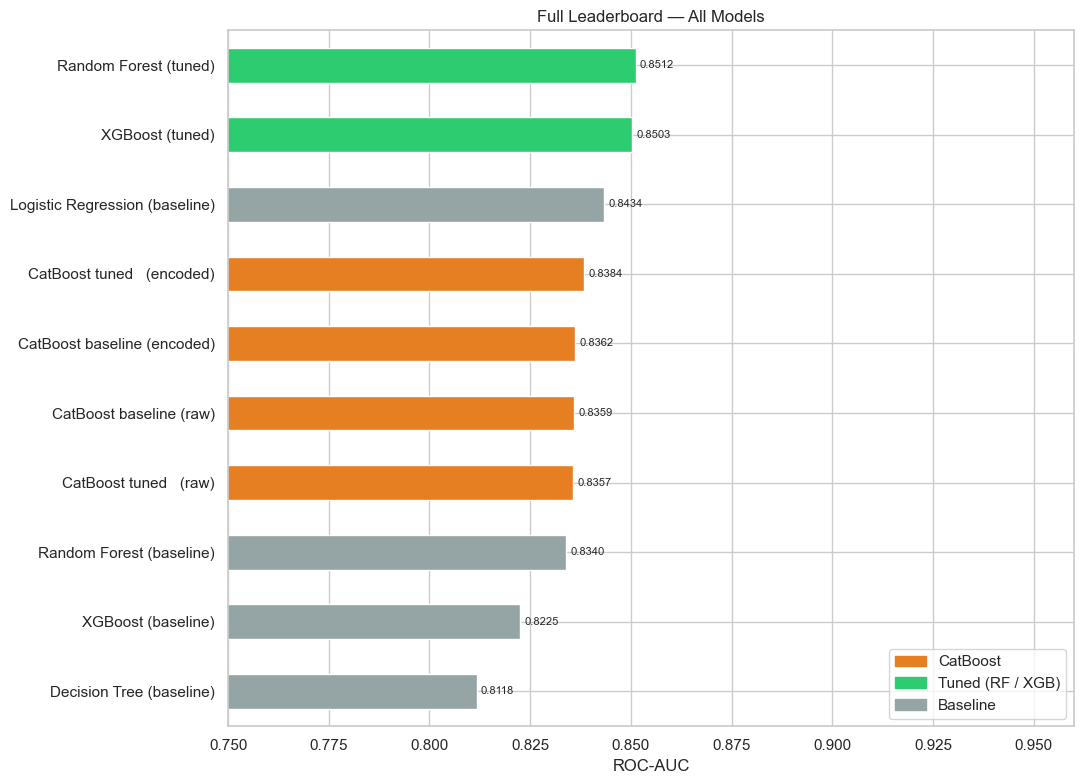

                                 ROC-AUC
Random Forest (tuned)           0.851199
XGBoost (tuned)                 0.850269
Logistic Regression (baseline)  0.843367
CatBoost tuned   (encoded)      0.838370
CatBoost baseline (encoded)     0.836209
CatBoost baseline (raw)         0.835931
CatBoost tuned   (raw)          0.835675
Random Forest (baseline)        0.834000
XGBoost (baseline)              0.822499
Decision Tree (baseline)        0.811787


In [24]:
all_results = {
    **{f"{k} (baseline)": v for k, v in baseline_results.items()},
    "Random Forest (tuned)": best_rf_auc,
    "XGBoost (tuned)":       best_xgb_auc,
    **cb_results,
}

leaderboard = (pd.DataFrame.from_dict(all_results, orient="index", columns=["ROC-AUC"])
               .sort_values("ROC-AUC", ascending=True))

fig, ax = plt.subplots(figsize=(11, 8))
palette = [
    "#e67e22" if "CatBoost" in k
    else "#2ecc71" if "tuned" in k
    else "#95a5a6"
    for k in leaderboard.index
]
leaderboard["ROC-AUC"].plot(kind="barh", ax=ax, color=palette)
ax.set_xlim(0.75, 0.96)
ax.set_title("Full Leaderboard — All Models")
ax.set_xlabel("ROC-AUC")
for i, v in enumerate(leaderboard["ROC-AUC"]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#e67e22", label="CatBoost"),
    Patch(color="#2ecc71", label="Tuned (RF / XGB)"),
    Patch(color="#95a5a6", label="Baseline"),
], loc="lower right")

plt.tight_layout()
plt.show()

print(leaderboard.sort_values("ROC-AUC", ascending=False).to_string())

## 9. Save Best Model

Random Forest (tuned) won with CV AUC = 0.8512 and Test AUC = 0.8356.

We serialize the model + the feature column order so the API can load both.


In [25]:
import joblib
import json
import os

os.makedirs("assets/model", exist_ok=True)

# Re-fit winner on the FULL dataset (train + val + test) before shipping
from sklearn.ensemble import RandomForestClassifier

best_rf_params = {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10}

production_model = RandomForestClassifier(
    **best_rf_params,
    class_weight="balanced",
    random_state=1,
    n_jobs=-1
)

In [27]:
# df_encoded and its Xy() split are available from the notebook session
# X_all / y_all = everything (train + val + test)
X_all = df_encoded.drop(columns=["churn"])
y_all = df_encoded["churn"].values

production_model.fit(X_all, y_all)

# Save model
joblib.dump(production_model, "assets/model/churn_model.pkl")

# Save feature names — API needs these to build the input vector in the right order
feature_names = X_all.columns.tolist()
with open("assets/model/feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

print("✅ Model saved → assets/model/churn_model.pkl")
print(f"✅ Features saved → assets/model/feature_names.json ({len(feature_names)} features)")
print("\nFeature order:")
for i, name in enumerate(feature_names):
    print(f"  {i:02d}. {name}")


✅ Model saved → assets/model/churn_model.pkl
✅ Features saved → assets/model/feature_names.json (24 features)

Feature order:
  00. gender
  01. senior_citizen
  02. is_married
  03. dependents
  04. tenure
  05. phone_service
  06. dual
  07. online_security
  08. online_backup
  09. device_protection
  10. tech_support
  11. streaming_tv
  12. streaming_movies
  13. contract
  14. paperless_billing
  15. monthly_charges
  16. total_charges
  17. internet_service_dsl
  18. internet_service_fiber_optic
  19. internet_service_no
  20. payment_method_bank_transfer_automatic
  21. payment_method_credit_card_automatic
  22. payment_method_electronic_check
  23. payment_method_mailed_check
